In [1]:
import torch 
import numpy as np
import warnings 


warnings.filterwarnings("ignore")

**Eqn 1** => y=3x <br>
**Eqn 2** => -5x+2y=2
=> 2y=2+5x
=> y=(2+5x)/2
=> y=1+(5x/2)


In [2]:
x=torch.linspace(-10,10,100)
y1=3*x
y2=1+((5*x)/2)

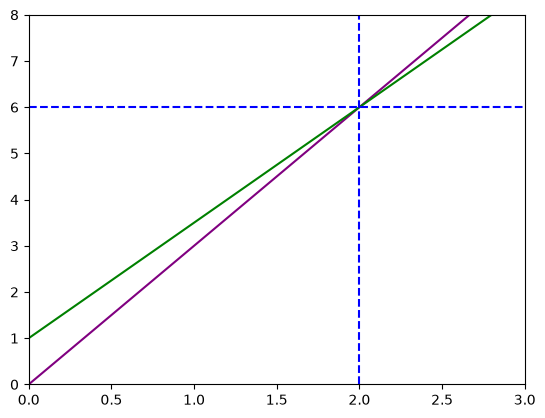

In [3]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots()
ax.plot(x,y1,color="purple")
ax.plot(x,y2,color="green")

ax.set_xlim([0,3])
ax.set_ylim([0,8])
ax.axvline(x=2,color="blue",linestyle="--")
ax.axhline(y=6,color="blue",linestyle="--")

**Tensor Operations**


In [4]:
a=torch.tensor([1,2,3])
b=torch.tensor([4,5,6])

# Element wise 

arthemetics = {
    "add":a+b,
    "subract":a-b,
    "hadamard or element product":a*b,
    "element wise div":a/b,
    "add int (3)":a+3,
    "subtract int(3)":a-3,
    "product int (10)":a*10,
    "divide int(10)":a/10
}


# matrix multiplication or dot prod

dot_product={
    "manual dot product of a and b":1*4+2*5+3*6,
    "functional dot of a and b":a.dot(b)
}

arthemetics,dot_product

({'add': tensor([5, 7, 9]),
  'subract': tensor([-3, -3, -3]),
  'hadamard or element product': tensor([ 4, 10, 18]),
  'element wise div': tensor([0.2500, 0.4000, 0.5000]),
  'add int (3)': tensor([4, 5, 6]),
  'subtract int(3)': tensor([-2, -1,  0]),
  'product int (10)': tensor([10, 20, 30]),
  'divide int(10)': tensor([0.1000, 0.2000, 0.3000])},
 {'manual dot product of a and b': 32,
  'functional dot of a and b': tensor(32)})

**Forbenius norm :- similar to L2 Norm**


In [5]:
arr=torch.tensor([[1.,2,3],[4.,5,6]])
torch.linalg.norm(arr)

tensor(9.5394)

**Matrix Multiplication or Dot Product**


In [6]:
A=torch.tensor([[3,4],[5,6],[7,8]])
B=torch.tensor([[1,9],[2,0]])
torch.matmul(A,B)

tensor([[11, 27],
        [17, 45],
        [23, 63]])

## **Matrix Inversion**

**For Non Singular**

y=x.w

multiplying inv(x) on both sides

inv(x).y=x.inv(x).w

we know that inv(x).x = I (identity matrix)

inv(x).y = I.w

we know that I (identity matrix) multiplied with w is w

therefore inv(x).y=w

in eqn 1 => 4b+2c = 4
and eqn 2=>-5b-3c = -7

x =[[4,2],
    [-5,-3]]

y = [4,7]

w = inv(x).y

w = [b,c]

**Note: can only done if number of row of X is equal to number of colums in Y not more nor less**->

**For Singular Matrix:No Solution**


In [7]:
X=torch.tensor([[4,2.],[-5,-3.]])
Y=torch.tensor([4,-7.])

inv_X=torch.linalg.inv(X)
W=torch.matmul(inv_X,Y)
W

tensor([-1.,  4.])

## Matrix transformations ( EigenVectors and EigenValues)


In [8]:
v=torch.tensor([3,2])
A=torch.tensor([[1,0],[0,-1]])

AV=torch.matmul(v,A)

AV

tensor([ 3, -2])

(-4.0, 4.0)

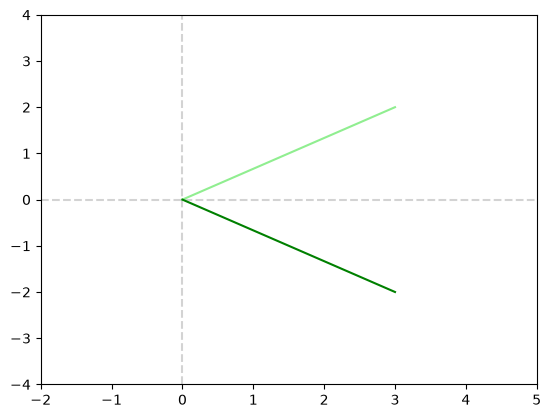

In [9]:
def plot_vectors(vectors:list[torch.Tensor|np.ndarray],colors:list[str]=None):
    
    l=len(vectors)
    
    if colors==None:
        colors=["lightgreen"]*l
    
    plt.figure()


    plt.axvline(x=0,color="lightgrey",linestyle="--")
    plt.axhline(y=0,color="lightgrey",linestyle="--")

    for i in range(l):
        plt.plot([0,vectors[i][0]],[0,vectors[i][1]],color=colors[i])
plot_vectors([v,AV],colors=["lightgreen","green"])
plt.xlim(-2,5)
plt.ylim(-4,4)

In [10]:
A=np.array([[-1,4],[2,-2]])
A

array([[-1,  4],
       [ 2, -2]])

In [11]:
lamdas,V=np.linalg.eig(A)
V,lamdas

(array([[ 0.86011126+0.j, -0.76454754+0.j],
        [ 0.51010647+0.j,  0.64456735+0.j]]),
 array([ 1.37228132+0.j, -4.37228132+0.j]))

In [12]:
A.dot(V)==lamdas*(V)

array([[ True,  True],
       [ True,  True]])

In [13]:
v=V[:,0]
v

array([0.86011126+0.j, 0.51010647+0.j])

In [14]:
lamb=lamdas[0]
Av=np.dot(A,v)
Av,lamb*v

(array([1.18031462+0.j, 0.70000958+0.j]),
 array([1.18031462+0.j, 0.70000958+0.j]))

(-2.0, 4.0)

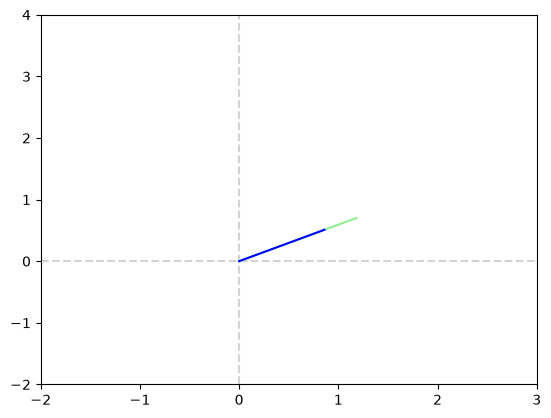

In [15]:
plot_vectors([Av,v],colors=["lightgreen","blue","yellow"])
plt.xlim([-2,3])
plt.ylim([-2,4])

### Determinants and eigen values 

det(X) = product(eigen values)  

volumetric change in Y due to application of X can be determined using determinants and eigen values   

cases :  

1. abs(det(X))>1 -> increase in Y volume   
2. 0<abs(det(X))<1 -> decrease in Y volume for some extent   
3. abs(det(X))=1 -> Y volume is exact volume as X 


In [16]:
X=torch.tensor([[3.,2],[4,1]])
det_X=torch.det(X)
L,V=torch.linalg.eig(X)
torch.prod(L)==det_X,det_X,L

(tensor(True), tensor(-5.), tensor([ 5.+0.j, -1.+0.j]))

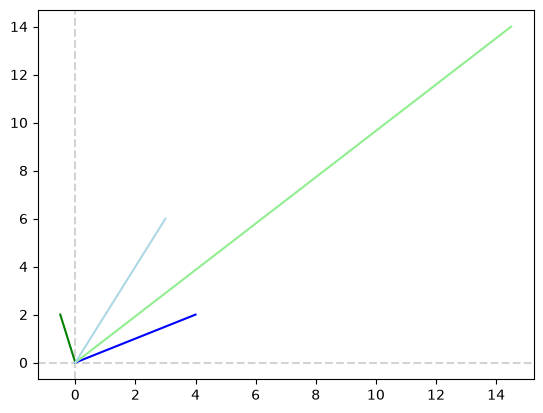

In [17]:
Y=torch.tensor([[-0.5,4],[2,2]])
XY=torch.matmul(Y,X)
plot_vectors([Y[:,0],Y[:,1],XY[:,0],XY[:,1]],colors=["green","blue","lightgreen","lightblue"])


### Eigen Decomposition   
reveals characteristic of a matrix  

1. matrix is singular if any of eigenvalues is 0
2. under some conditions can optimize a quadratic eqn (f(x))
    - max(f(x)) = max(eigenvalues(f(x)))
    - min(f(x)) = min(eigenvalues(f(x)))  

A = V.diag(eigenvals).inv(V)

where V = eigen vectors


In [35]:
A=torch.tensor([[4,2.],[-5,-3]],dtype=torch.float32)
L,V=torch.linalg.eig(A)
L,A

(tensor([ 2.+0.j, -1.+0.j]),
 tensor([[ 4.,  2.],
         [-5., -3.]]))

In [39]:
diag_L=torch.diag(L)
inv_V=torch.linalg.inv(V)
torch.matmul(V,torch.matmul(diag_L,inv_V)),A

(tensor([[ 4.0000+0.j,  2.0000+0.j],
         [-5.0000+0.j, -3.0000+0.j]]),
 tensor([[ 4.,  2.],
         [-5., -3.]]))